<a href="https://colab.research.google.com/github/bagascahyawiguna/SIRUPI/blob/main/MachineLearning/SIRUPI_YOLOV8N.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SIRUPI MODEL TRAINING USING YOLOV8N**

## **1. Import Library & Konfigurasi Lingkungan**
Tahap ini mencakup proses impor library yang dibutuhkan untuk pelatihan model
YOLOv8 serta konfigurasi direktori dataset yang tersimpan pada Google Drive.
Seluruh proses dilakukan pada lingkungan Google Colab.

### **1.1 Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **1.2 Install & Import Library YOLOv8**

In [ ]:
# Install Ultralytics YOLOv8
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.8 MB/s eta 0:00:00


### **1.3 Import Library Utama**

In [ ]:
import os
from pathlib import Path
import yaml
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


### **1.4 Konfigurasi Path Dataset**

In [ ]:
YOLO_BASE_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO"
)

IMAGES = YOLO_BASE_PATH / "images"
LABELS = YOLO_BASE_PATH / "labels"

print("YOLO Primer:", YOLO_BASE_PATH)

YOLO Primer: /content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO


### **1.5 Verifikasi Struktur Dataset**

In [ ]:
def check_yolo_structure(base_path):
    print(f"\nMengecek dataset di: {base_path}")

    for split in ["train", "val", "test"]:
        img_dir = base_path / "images" / split
        lbl_dir = base_path / "labels" / split

        print(f"\n▶ {split.upper()}")

        print(" Images:", "OK" if img_dir.exists() else "Tidak ditemukan")
        print(" Labels:", "OK" if lbl_dir.exists() else "Tidak ditemukan")

        if img_dir.exists():
            img_count = sum(len(list(img_dir.glob(ext))) for ext in ["*.jpg", "*.png", "*.jpeg"])
            print("   Jumlah gambar:", img_count)

        if lbl_dir.exists():
            lbl_count = len(list(lbl_dir.glob("*.txt")))
            print("   Jumlah label :", lbl_count)

check_yolo_structure(YOLO_BASE_PATH)


Mengecek dataset di: /content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO

▶ TRAIN
 Images: OK
 Labels: OK
   Jumlah gambar: 8369
   Jumlah label : 8369

▶ VAL
 Images: OK
 Labels: OK
   Jumlah gambar: 1097
   Jumlah label : 1097

▶ TEST
 Images: OK
 Labels: OK
   Jumlah gambar: 988
   Jumlah label : 988


## **2. Validasi File Label YOLO**
Tahap ini bertujuan untuk memastikan bahwa seluruh file label YOLO memiliki format
yang valid, tidak kosong, serta memiliki nilai bounding box yang sesuai dengan
spesifikasi YOLO sebelum proses pelatihan model dilakukan.

### **2.1 Konfigurasi Awal**

In [ ]:
from pathlib import Path

YOLO_BASE_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO"
)

CLASSES = ['1k', '2k', '5k', '10k', '20k', '50k', '100k']
NUM_CLASSES = len(CLASSES)

### **2.2 Cek Label Kosong & Format Dasar**

In [ ]:
from tqdm import tqdm

def check_empty_and_format(split):
    label_dir = YOLO_BASE_PATH / "labels" / split
    empty_files = []
    malformed_files = []

    for label_file in tqdm(list(label_dir.glob("*.txt")), desc=f"Checking {split}"):
        with open(label_file, "r") as f:
            lines = f.readlines()

        if len(lines) == 0:
            empty_files.append(label_file.name)
            continue

        for line in lines:
            parts = line.strip().split()
            if len(parts) != 5:
                malformed_files.append(label_file.name)
                break

    print(f"\n▶ {split.upper()}")
    print(f"Label kosong       : {len(empty_files)}")
    print(f"Format tidak valid : {len(malformed_files)}")

    return empty_files, malformed_files

for split in ['train', 'val', 'test']:
    check_empty_and_format(split)

Checking train: 100%|██████████| 8369/8369 [02:52<00:00, 48.59it/s] 



▶ TRAIN
Label kosong       : 15
Format tidak valid : 0


Checking val: 100%|██████████| 1097/1097 [00:17<00:00, 61.65it/s] 



▶ VAL
Label kosong       : 2
Format tidak valid : 0


Checking test: 100%|██████████| 988/988 [00:15<00:00, 62.79it/s] 


▶ TEST
Label kosong       : 0
Format tidak valid : 0


#### **2.2.1 Menghapus gambar yang memiliki label kosong**

In [ ]:
def remove_empty_labels(split):
    img_dir = YOLO_BASE_PATH / "images" / split
    lbl_dir = YOLO_BASE_PATH / "labels" / split

    removed = 0
    for lbl in lbl_dir.glob("*.txt"):
        if lbl.stat().st_size == 0:
            img = img_dir / f"{lbl.stem}.jpg"
            lbl.unlink()
            if img.exists():
                img.unlink()
            removed += 1

    print(f"{split}: dihapus {removed} sample kosong")

for s in ["train","val","test"]:
    remove_empty_labels(s)

train: dihapus 15 sample kosong
val: dihapus 2 sample kosong
test: dihapus 0 sample kosong


### **2.3 Validasi Nilai Bounding Box & Class ID**

In [ ]:
def check_bbox_and_class(split):
    label_dir = YOLO_BASE_PATH / "labels" / split

    invalid_bbox = []
    invalid_class = []

    for label_file in tqdm(list(label_dir.glob("*.txt")), desc=f"Validating {split}"):
        with open(label_file, "r") as f:
            for line in f:
                cls_id, x, y, w, h = map(float, line.split())

                if not (0 <= cls_id < NUM_CLASSES):
                    invalid_class.append(label_file.name)

                if not (0 < x <= 1 and 0 < y <= 1 and 0 < w <= 1 and 0 < h <= 1):
                    invalid_bbox.append(label_file.name)

    print(f"\n▶ {split.upper()}")
    print(f"Class ID tidak valid : {len(set(invalid_class))}")
    print(f"BBox tidak valid     : {len(set(invalid_bbox))}")

    return invalid_class, invalid_bbox

for split in ['train', 'val', 'test']:
    check_bbox_and_class(split)

Validating train: 100%|██████████| 8354/8354 [01:17<00:00, 107.42it/s]



▶ TRAIN
Class ID tidak valid : 0
BBox tidak valid     : 0


Validating val: 100%|██████████| 1095/1095 [00:05<00:00, 186.95it/s]



▶ VAL
Class ID tidak valid : 0
BBox tidak valid     : 0


Validating test: 100%|██████████| 988/988 [00:05<00:00, 197.49it/s]


▶ TEST
Class ID tidak valid : 0
BBox tidak valid     : 0


## **3. Persiapan & Training Model YOLOv8n**
Tahap ini bertujuan untuk melatih model YOLOv8n menggunakan dataset yang telah
dikonversi dan divalidasi. YOLOv8n dipilih karena memiliki ukuran model yang kecil dan efisien sehingga sesuai untuk integrasi pada aplikasi mobile.

### **3.1 Instalasi Library**

In [ ]:
!pip install -U ultralytics

### **3.2 Import & Cek Versi**

In [ ]:
from ultralytics import YOLO

import torch
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

PyTorch version : 2.9.0+cu126
CUDA available  : True


### **3.3 Membuat data.yaml**

In [ ]:
from pathlib import Path

yaml_path = Path("/content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO/data.yaml")

yaml_content = """
path: /content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO
train: images/train
val: images/val
test: images/test

names:
  0: 1k
  1: 2k
  2: 5k
  3: 10k
  4: 20k
  5: 50k
  6: 100k
"""

yaml_path.parent.mkdir(parents=True, exist_ok=True)
yaml_path.write_text(yaml_content)

print("data.yaml berhasil dibuat di:", yaml_path)


data.yaml berhasil dibuat di: /content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO/data.yaml


In [ ]:
!cat "/content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO/data.yaml"


path: /content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO
train: images/train
val: images/val
test: images/test

names:
  0: 1k
  1: 2k
  2: 5k
  3: 10k
  4: 20k
  5: 50k
  6: 100k


### **3.4 Konfigurasi Path Dataset**

In [ ]:
DATA_YAML = "/content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO/data.yaml"

### **3.5 Load Model YOLOv8n (Pretrained)**

In [ ]:
model = YOLO("yolov8n.pt")

### **3.6 Konfigurasi Training (Mobile-Friendly)**

In [ ]:
model.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    optimizer="Adam",
    lr0=1e-4,
    patience=10,
    device=0,
    project="SIRUPI_YOLO",
    name="yolov8n_currency"
)

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_currency, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7fbc27b07740>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

## **4. Evaluasi Model**

### **4.1 Load Model Terbaik**

In [ ]:
from ultralytics import YOLO

# Path ke model terbaik
MODEL_PATH = "/content/SIRUPI_YOLO/yolov8n_currency/weights/best.pt"

# Load model
model = YOLO(MODEL_PATH)

print("Model berhasil dimuat:", MODEL_PATH)

Model berhasil dimuat: /content/SIRUPI_YOLO/yolov8n_currency/weights/best.pt


### **4.2 Evaluasi pada TEST SET**

In [ ]:
!yolo detect val \
  model=/content/SIRUPI_YOLO/yolov8n_currency/weights/best.pt \
  data="/content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO/data.yaml" \
  split=test

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,013 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.0±0.0 MB/s, size: 7.4 KB)
val: Scanning /content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO/labels/test... 988 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 988/988 33.6it/s 29.4s
val: New cache created: /content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 5.3it/s 11.8s
                   all        988        989      0.994      0.992      0.995      0.959
                    1k        131        131      0.996          1      0.995      0.963
                    2k        132        132       0.99      0.977      0.994      0.956
                    5k        143        143          1      0.994      0.995       0.97
         

### **4.3 Confusion Matrix**

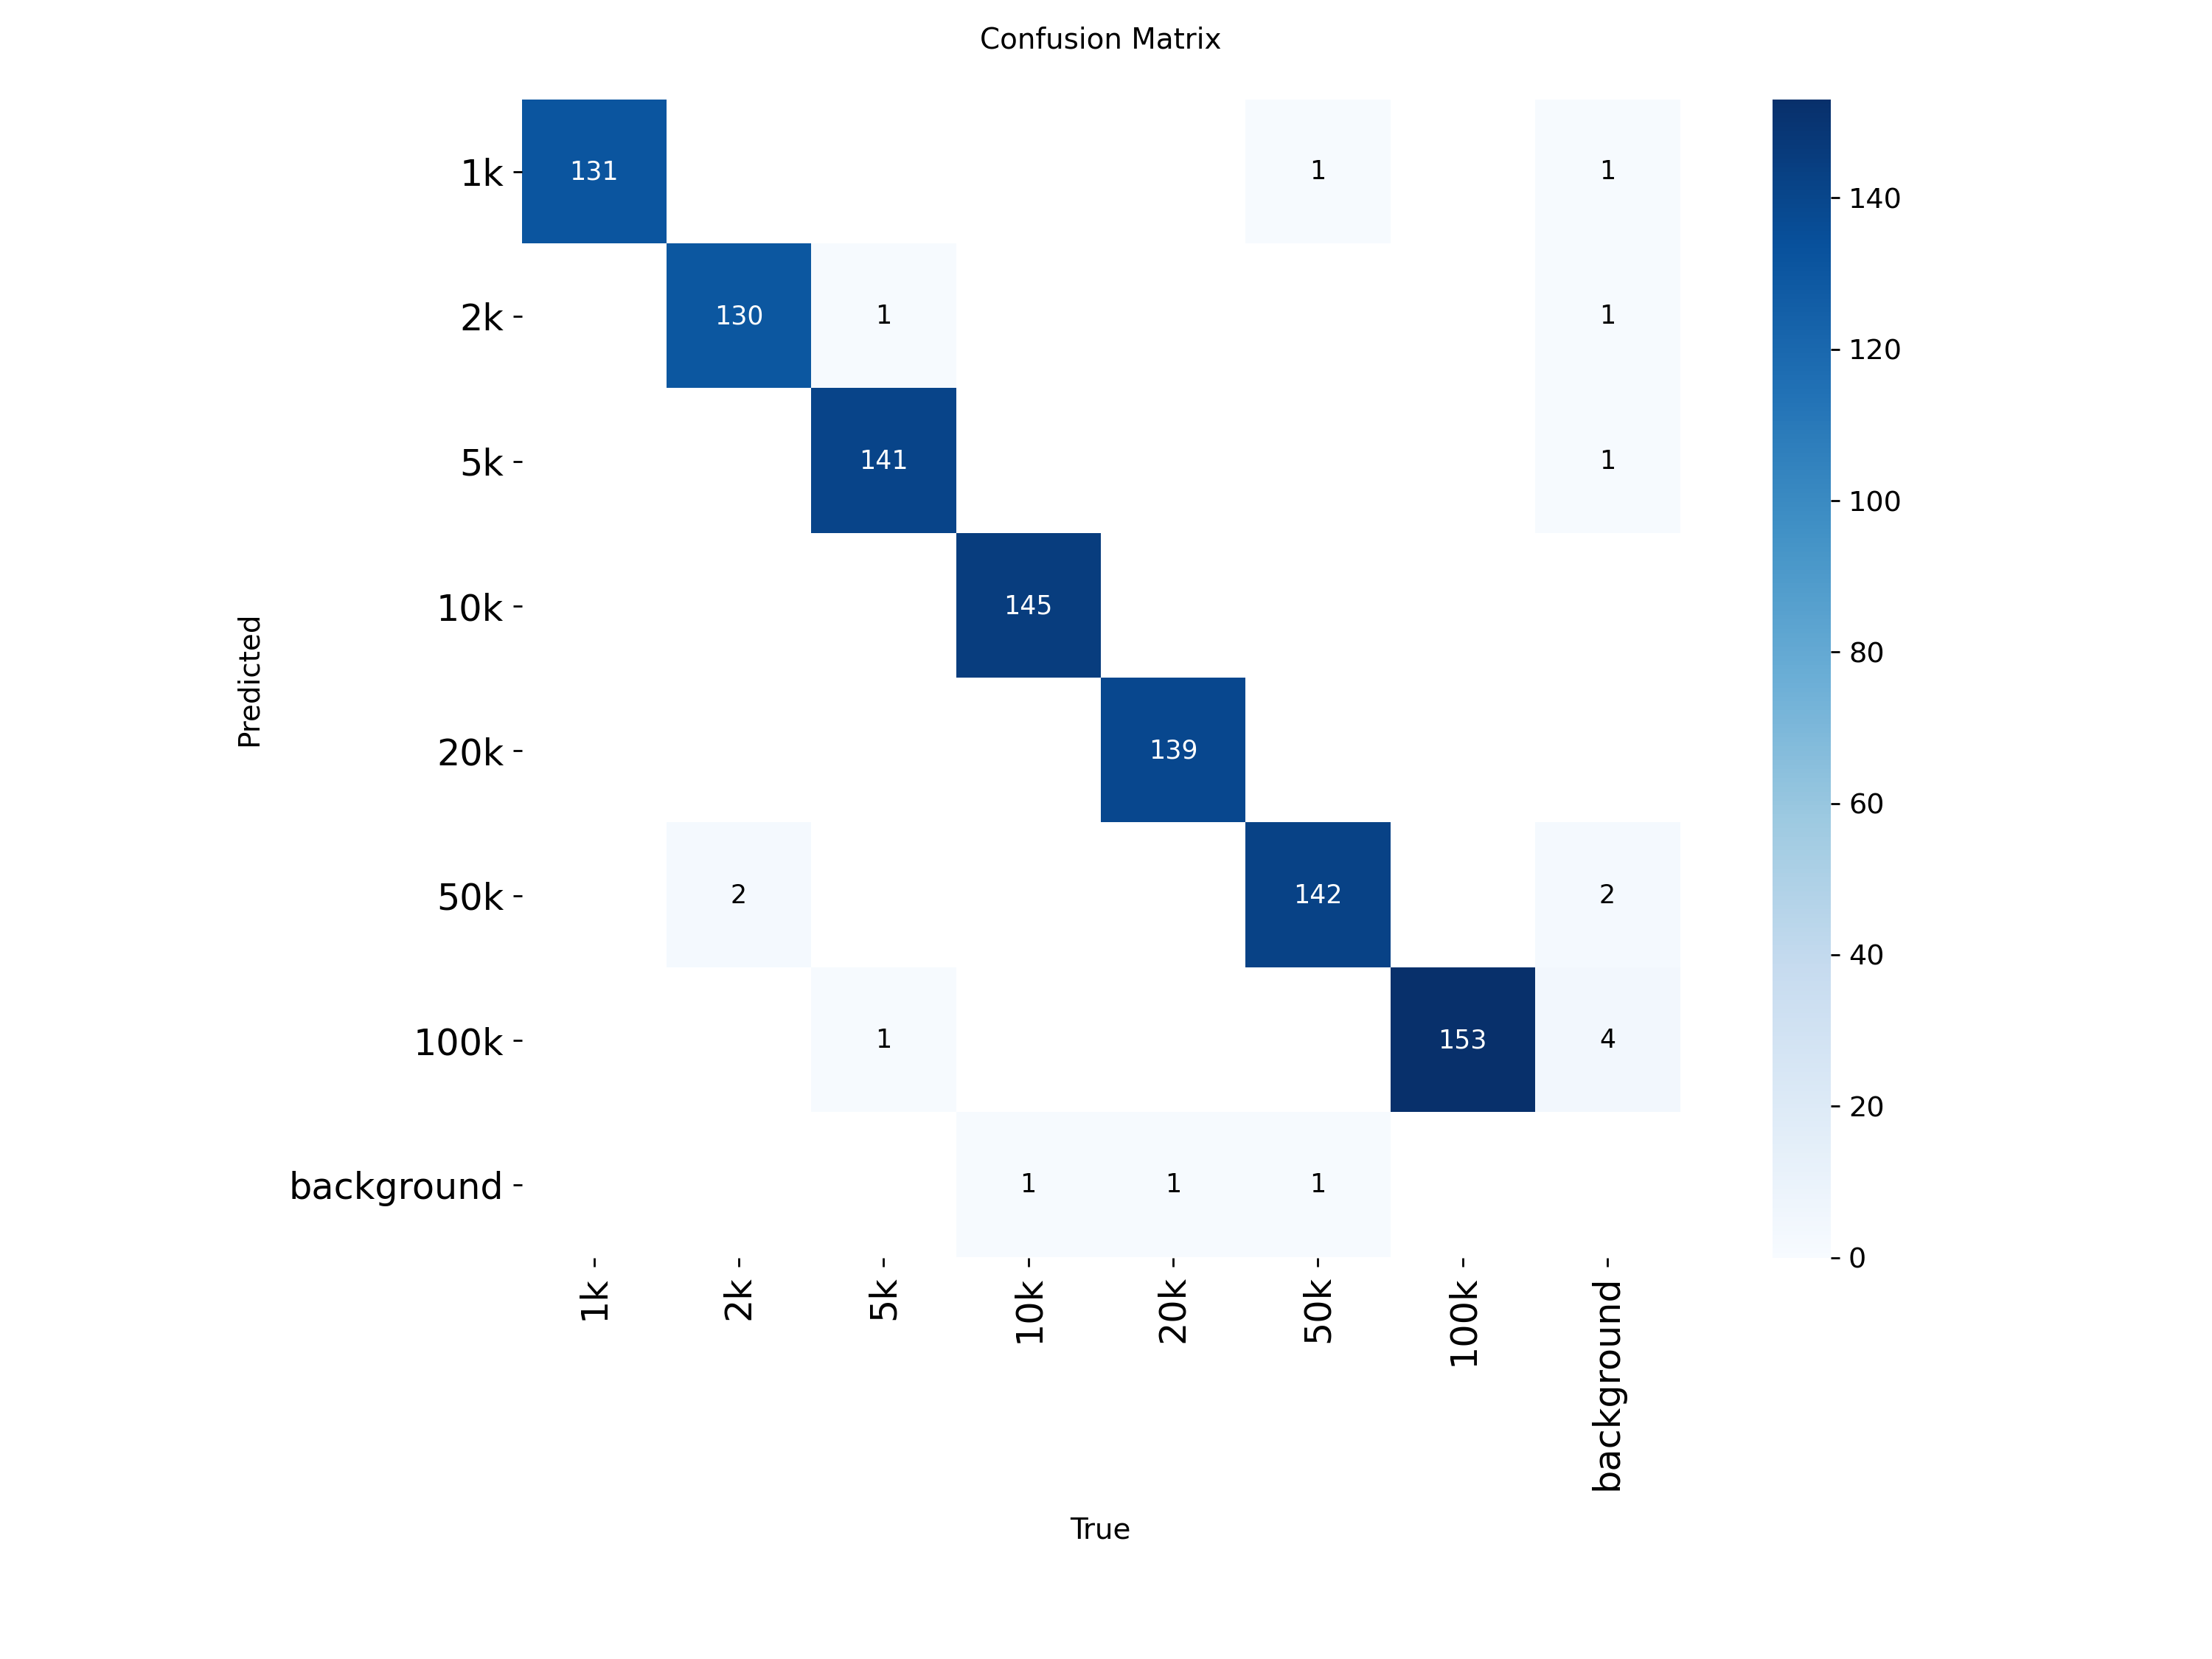

In [ ]:
from IPython.display import Image, display

CONF_MATRIX_PATH = "/content/runs/detect/val/confusion_matrix.png"

display(Image(filename=CONF_MATRIX_PATH))

### **4.4 Kurva Precision, Recall, F1, dan PR**

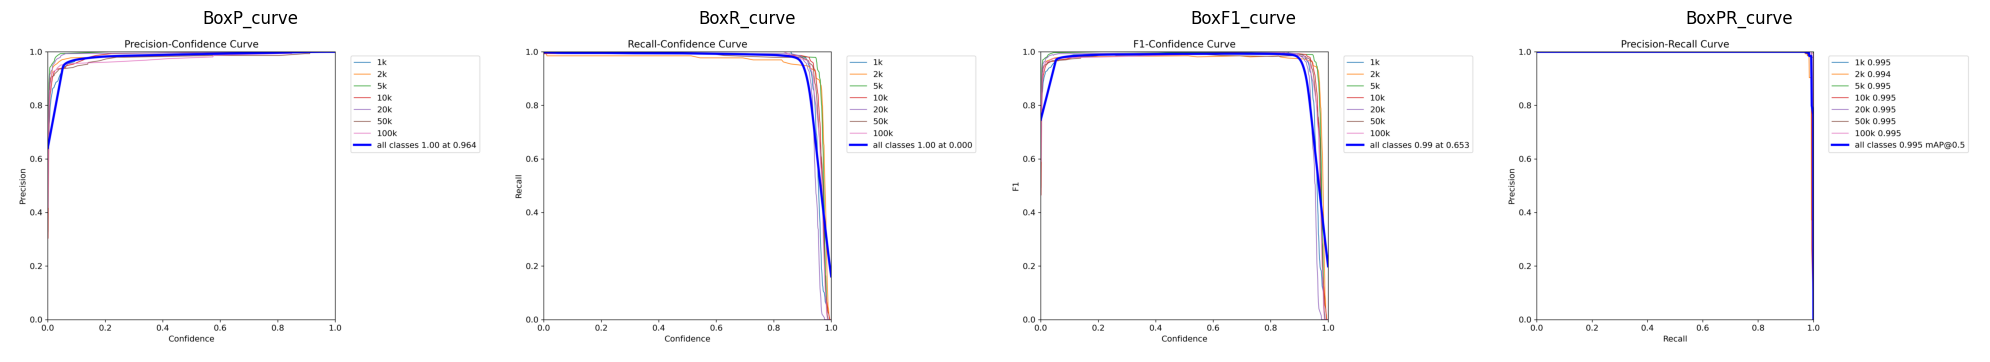

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

BASE_VAL_PATH = "/content/runs/detect/val"
curve_files = ["BoxP_curve.png", "BoxR_curve.png", "BoxF1_curve.png", "BoxPR_curve.png"]

# Membuat layout plot (1 baris, 4 kolom)
plt.figure(figsize=(20, 5))

for i, f in enumerate(curve_files):
    path = os.path.join(BASE_VAL_PATH, f)
    if os.path.exists(path):
        img = mpimg.imread(path)
        plt.subplot(1, 4, i + 1) # Posisi gambar ke-i
        plt.imshow(img)
        plt.axis('off') # Hilangkan axis angka
        plt.title(f.replace(".png", "")) # Judul gambar
    else:
        print(f"File {f} tidak ditemukan.")

plt.tight_layout()
plt.show()

### **4.5 Uji "Robustness" (Ketahanan)**


image 1/1 /content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO/images/test/aug_308.jpg: 640x640 1 100k, 7.3ms
Speed: 3.5ms preprocess, 7.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)


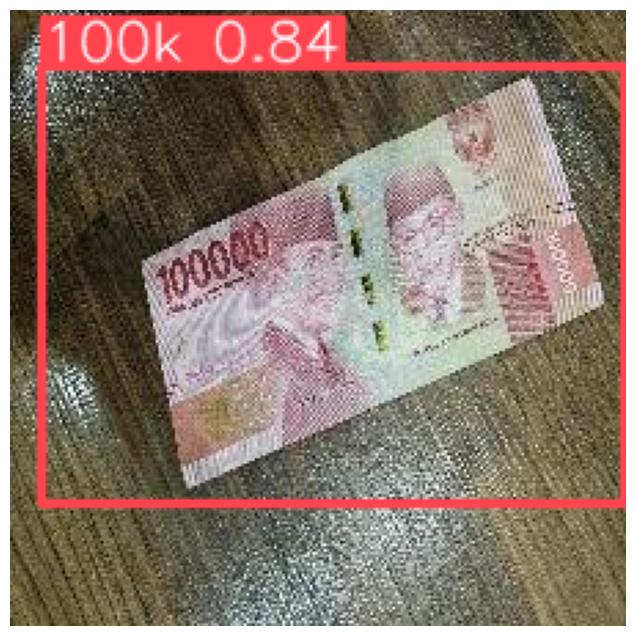

In [ ]:
# Contoh kode uji coba manual
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load model terbaik
model = YOLO("/content/SIRUPI_YOLO/yolov8n_currency/weights/best.pt")

# Ganti dengan path foto tes manual Anda (misal foto uang lecek)
img_path = "/content/drive/MyDrive/Colab Notebooks/SIRUPI/SIRUPI_YOLO/images/test/aug_308.jpg"

# Prediksi dengan threshold yang kita diskusikan (0.45)
results = model.predict(img_path, conf=0.45)

# Tampilkan hasil
for result in results:
    im_array = result.plot()  # plot bounding box
    plt.figure(figsize=(8,8))
    plt.imshow(cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

## **5. Export Model**

In [ ]:
model.export(format='tflite')

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/SIRUPI_YOLO/yolov8n_currency/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 11, 8400) (6.0 MB)
requirements: Ultralytics requirements ['sng4onnx>=1.0.1', 'onnx_graphsurgeon>=0.3.26', 'ai-edge-litert>=1.2.0', 'onnx>=1.12.0,<2.0.0', 'onnx2tf>=1.26.3', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 20 packages in 1.95s
Prepared 11 packages in 6.18s
Installed 11 packages in 260ms
 + ai-edge-litert==2.1.0
 + backports-strenum==1.3.1
 + colorama==0.4.6
 + coloredlogs==15.0.1
 + humanfriendly==10.0
 + onnx==1.20.0
 + onnx-graphsurgeon==0.5.8
 + onnx2tf==1.28.6
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.80
 + sng4onnx==1.0.4


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/utils.py:1447: OnnxExporterWarning: Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 
  warnings.warn(


ONNX: slimming with onnxslim 0.1.80...
ONNX: export success ✅ 1.4s, saved as '/content/SIRUPI_YOLO/yolov8n_currency/weights/best.onnx' (11.8 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 51.2files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.6...
Saved artifact at '/content/SIRUPI_YOLO/yolov8n_currency/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 11, 8400), dtype=tf.float32, name=None)
Captures:
  140446393254352: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  140446400232336: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  140446393254544: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  140446393258960: TensorSpec(shape=(4, 2), dty

'/content/SIRUPI_YOLO/yolov8n_currency/weights/best_saved_model/best_float32.tflite'

In [ ]:
from google.colab import files

# Path file model TFLite Anda
file_path = '/content/SIRUPI_YOLO/yolov8n_currency/weights/best_saved_model/best_float32.tflite'

print(f"Sedang mencoba mengunduh: {file_path}")
try:
    files.download(file_path)
except FileNotFoundError:
    print("File tidak ditemukan. Mohon cek kembali path atau pastikan proses export sudah selesai.")

Sedang mencoba mengunduh: /content/SIRUPI_YOLO/yolov8n_currency/weights/best_saved_model/best_float32.tflite


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>